In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import scipy.stats as stats
import galsim

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0528 09:50:56.628628 139692148246336 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


### Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/26.5/test/' # mag cut at 26.5 in r band

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

In [4]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v2 = root_dir_models+'v_test/loss/'#'v14/loss/'  # concat only after all convolution blocks
dir_model_v3 = root_dir_models+'v15/loss/'#'v15/loss/'  # No use of PSF
dir_model_v4 = root_dir_models+'v_cyrille_small_batch_size/loss/' # Model cyrille
dir_model_v5 = root_dir_models+'v17/loss/'#'v17/loss/'  # BNN with concat after all convolution blocks

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [60]:
images = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

#ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
#ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))

In [67]:
ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))

In [70]:
ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

ellipticity_1 = calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence)

e1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
e2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)

In [71]:
-e1, ellipticity_1

(array([-0.11195271, -0.02973772,  0.26337841, ...,  0.05169117,
        -0.04059943,  0.00227266]),
 array([-0.10418754, -0.03060404,  0.28531563, ...,  0.04276431,
        -0.02966265,  0.00270374]))

In [72]:
e2, ellipticity_2

(array([-0.3764409 ,  0.07057628,  0.11491012, ..., -0.08162324,
         0.01782735, -0.02160054]),
 array([-0.37700214,  0.07057221,  0.11350815, ..., -0.08168464,
         0.01784471, -0.02160049]))

In [7]:
model_concat_one = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_no_psf = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_cyrille = model.create_model_cyrille(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_bnn = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0528 09:51:16.700136 139692148246336 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0528 09:51:17.414694 139692148246336 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.
W0528 09:51:18.829108 139692148246336 deprecation.py:323] From ../../scripts/tools_for_VAE/tool

[8192, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


In [8]:
latest = tf.train.latest_checkpoint(dir_model_v2)
model_concat_one.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v3)
model_no_psf.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v4)
model_cyrille.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v5)
model_bnn.load_weights(latest)

### Shear bias estimation

In [97]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)    

    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####

    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    print(exp)
    handles = []
    for ik, key in enumerate(exp):
        print(ik, key)
        stats = {}
        for i in range(1,len(x_bins)):
            #print(np.mean(df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values))
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values#[np.logical_and(idx==i,df_plot[z]==key)]
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)
            #print(slope-1,intercept,)
            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [98]:
df_plot_hsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   blendedness     2000 non-null   float64
 1   convergence     2000 non-null   float64
 2   e1              2000 non-null   float64
 3   e1_hsm_regauss  1998 non-null   float64
 4   e2              2000 non-null   float64
 5   e2_hsm_regauss  1998 non-null   float64
 6   id              2000 non-null   int64  
 7   mag_r_meas      2000 non-null   float64
 8   mag_r_true      2000 non-null   float64
 9   redshift        2000 non-null   float64
 10  redshift_true   2000 non-null   float64
 11  shear_1         2000 non-null   float64
 12  shear_2         2000 non-null   float64
 13  snr_r           2000 non-null   float64
 14  e1_error        1999 non-null   float64
 15  e2_error        1999 non-null   float64
 16  exp             2000 non-null   int64  
 17  e1_meas         1999 non-null   f

In [99]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1[:nb_of_points],-e1[:nb_of_points]])
df_plot_hsm['e2_sheared'] = np.concatenate([e2[:nb_of_points],e2[:nb_of_points]])

In [100]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

df_plot_hsm['e1_conv'] = -ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

## Add shear with galsim

In [12]:
import galsim

In [10]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')

images.shape

(10000, 59, 59, 6)

In [13]:
image_galsim = galsim.Image(images[0,:,:,0], copy=True)
test = galsim.InterpolatedImage(image_galsim,scale = 0.2)
s = galsim.Shear(g1=-0.01, g2=0.)

In [14]:
test = test.shear(s)

image = galsim.ImageF(59, 59, scale=0.2)
_ = test.drawImage(image=image)
test_img = image.array.data

In [15]:
psf_image = galsim.Image(psf[0,:,:,0], copy=True)
galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
inv_psf = galsim.Deconvolve(galsim_psf)

image_galsim = galsim.Image(images[0,:,:,0], copy=True)
galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)

deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)

gamma1 = 0.
gamma2 = 0.

s = galsim.Shear(g1=gamma1,g2=gamma2)

# Shear galsim object
deconv_galsim_obj = deconv_galsim_obj.shear(s)

# recconvolve by PSF
conv_galsim_obj = galsim.Convolve(galsim_psf, deconv_galsim_obj)

# Reconstruct image from sheared object
image = galsim.ImageF(59, 59, scale=0.2)
_ = conv_galsim_obj.drawImage(image=image)
test_img = image.array.data

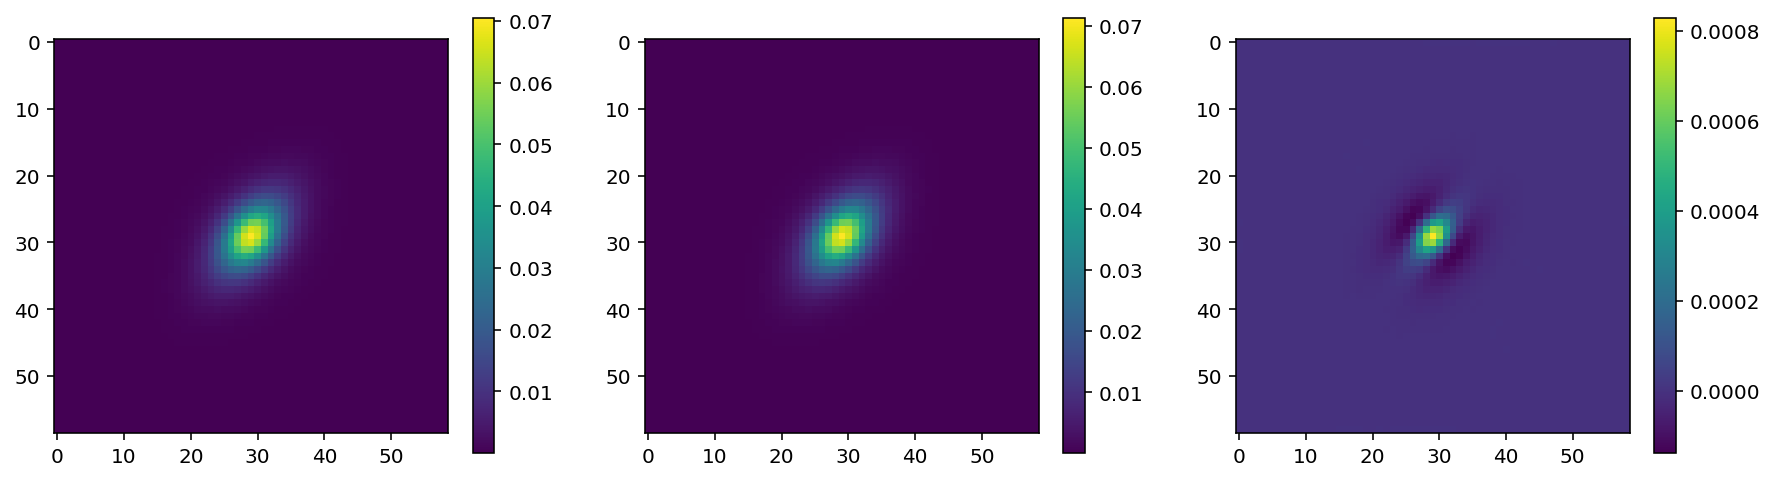

In [16]:
fig, axes = plt.subplots(1,3, figsize = (15,4))
fig1 = axes[0].imshow(test_img)
fig2 = axes[1].imshow(images[0,:,:,0])
fig3 = axes[2].imshow(images[0,:,:,0]-test_img)

fig.colorbar(fig1, ax = axes[0])
fig.colorbar(fig2, ax = axes[1])
fig.colorbar(fig3, ax = axes[2])

In [ ]:
n_images = 10000
image_sheared = np.zeros((4,n_images,59,59,6))
shears = [(0.01,0), (-0.01,0), (0,0.01), (0,-0.01)]

for z, input_shear in enumerate(shears):
    for i in range (n_images):
        for k in range (len(images[0,0,0])):
            psf_image = galsim.Image(psf[i,:,:,k], copy=True)
            galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
            inv_psf = galsim.Deconvolve(galsim_psf)
            
            image_galsim = galsim.Image(images[i,:,:,k], copy=True)
            galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)
            
            deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)
            
            gamma1 = input_shear[0]
            gamma2 = input_shear[1]

            s = galsim.Shear(g1=gamma1,g2=gamma2)

            # Shear galsim object
            deconv_galsim_obj = deconv_galsim_obj.shear(s)

            # recconvolve by PSF
            conv_galsim_obj = galsim.Convolve(galsim_psf, deconv_galsim_obj)
            
            # Reconstruct image from sheared object
            image = galsim.ImageF(59, 59, scale=0.2)
            _ = conv_galsim_obj.drawImage(image=image)
            image_sheared[z,i,:,:,k] = image.array.data

In [ ]:
np.save(root_dir_v1+'sheared_images.npy', image_sheared)

In [17]:
image_sheared = np.load(root_dir_v1+'sheared_images.npy', mmap_mode = 'c')
print(image_sheared.shape)

(4, 10000, 59, 59, 6)


Text(0.5, 1.0, '$g(0,0)-g(0,-0.01)$')

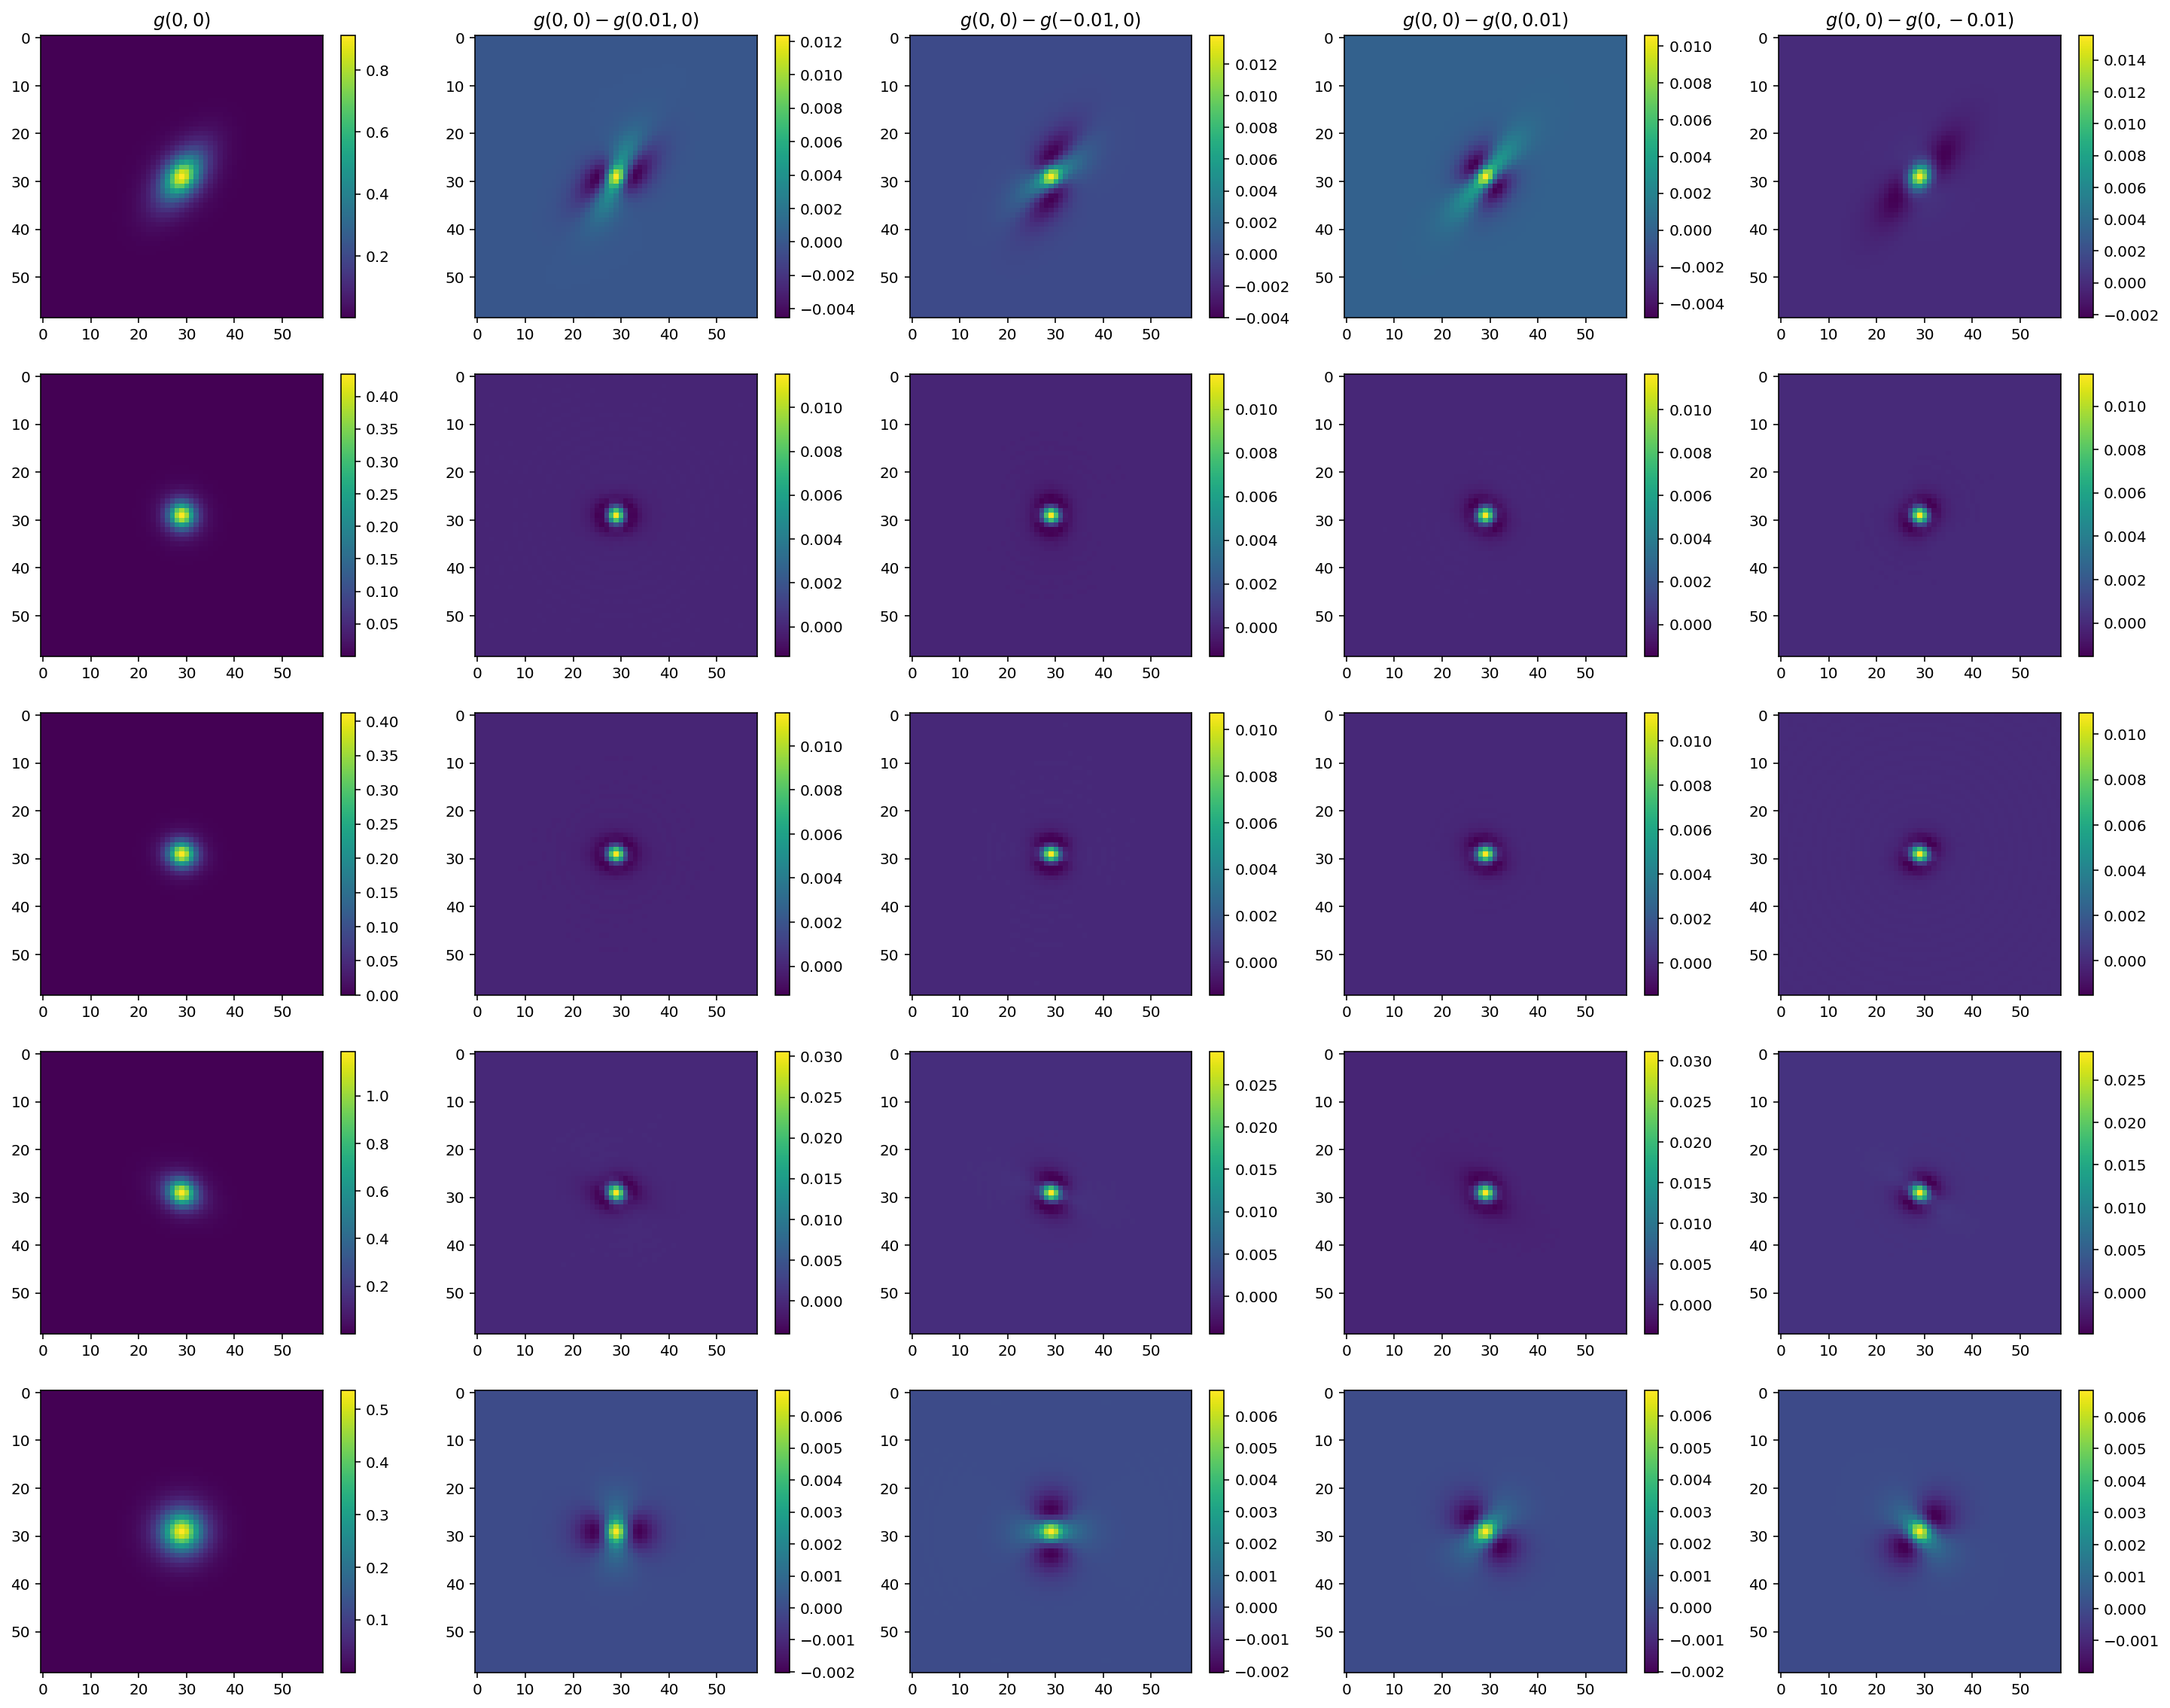

In [18]:
fig, ax = plt.subplots(5, 5, figsize = (25,20))
cm = ['RdBu_r']
      
for i in range (5):
    img = ax[i,0].imshow(images[i,:,:,2])
    fig.colorbar(img, ax=ax[i,0])
    img = ax[i,1].imshow(images[i,:,:,2]- image_sheared[0,i,:,:,2])
    fig.colorbar(img, ax=ax[i,1])
    img = ax[i,2].imshow(images[i,:,:,2]- image_sheared[1,i,:,:,2])
    fig.colorbar(img, ax=ax[i,2])
    img = ax[i,3].imshow(images[i,:,:,2]- image_sheared[2,i,:,:,2])
    fig.colorbar(img, ax=ax[i,3])
    img = ax[i,4].imshow(images[i,:,:,2]- image_sheared[3,i,:,:,2])
    fig.colorbar(img, ax=ax[i,4])
    
ax[0,0].set_title('$g(0,0)$')
ax[0,1].set_title('$g(0,0)-g(0.01,0)$')
ax[0,2].set_title('$g(0,0)-g(-0.01,0)$')
ax[0,3].set_title('$g(0,0)-g(0,0.01)$')
ax[0,4].set_title('$g(0,0)-g(0,-0.01)$')

## Compute shear bias on all sample

In [9]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
image_sheared = np.load(root_dir_v1+'sheared_images.npy', mmap_mode = 'c')

### Case (0,0)

#### Model no PSF

In [ ]:
output_v1 = model_no_psf([tf.cast(images, tf.float32), tf.cast(psf, tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1
df['e2_input'] = e2

df.to_csv('data/res_no_psf_0_0.csv')

In [40]:
df = pd.read_csv('data/res_no_psf_0_0.csv')

In [21]:
import statsmodels.api as sm

df_bias_0_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']

    x = sm.add_constant(x, prepend=False)

    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_0['mean_e'] = np.mean([df_bias_0_0['slope_e1'],df_bias_0_0['slope_e2']], axis = 0)

df_bias_0_0

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/numpy/core/fromnumeric.py:2580: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.031437,0.002414,0.000532,0.000133,0.004786,0.030378,0.000572,0.000492,0.000121,-0.004908,0.030908


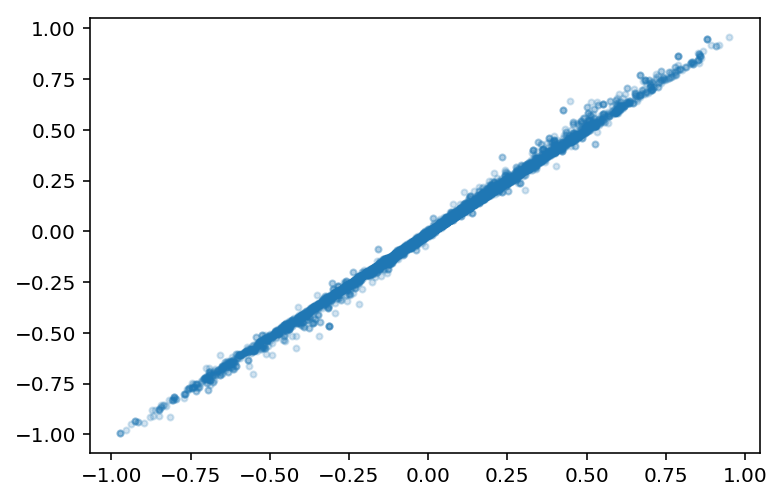

In [22]:
plt.plot(df['e1_input']+0.01,df['e1_res_mean'], '.', alpha = 0.2)

### Case (0.01,0)

#### Model no PSF

In [ ]:
output_v1 = model_no_psf([tf.cast(image_sheared[0], tf.float32), tf.cast(psf, tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1
df['e2_input'] = e2

df.to_csv('data/res_no_psf_p001_0.csv')

In [23]:
df = pd.read_csv('data/res_no_psf_p001_0.csv')

In [24]:
import statsmodels.api as sm

df_bias_p001_0 = pd.DataFrame()


for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']-0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))#df_test['e'+str(k+1)+'_out'][mask]
    
    df_bias_p001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_p001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_p001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_p001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_p001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_p001_0['mean_e'] = np.mean([df_bias_p001_0['slope_e1'],df_bias_p001_0['slope_e2']], axis = 0)
df_bias_p001_0

,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.010669,-0.00676,0.000402,0.000101,-0.014542,0.011958,0.010561,0.000348,0.000086,-0.004941,0.011314


### Model deterministic with PSF

In [ ]:
output_v1 = model_concat_one([tf.cast(image_sheared[0][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_p001_0.csv')

In [25]:
df = pd.read_csv('data/res_det_psf_p001_0.csv')

In [26]:
import statsmodels.api as sm

df_bias_p001_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']-0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))#df_test['e'+str(k+1)+'_out'][mask]
    
    df_bias_p001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_p001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_p001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_p001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_p001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_p001_0['mean_e'] = np.mean([df_bias_p001_0['slope_e1'],df_bias_p001_0['slope_e2']], axis = 0)
df_bias_p001_0


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.012937,-0.013274,0.000827,0.000205,-0.026074,0.015567,0.007061,0.000686,0.000168,-0.008273,0.014252


In [27]:
stats.linregress(df['e1_input']-0.01, df['e1_res_mean'])

LinregressResult(slope=1.012936826802953, intercept=-0.013274233096168606, rvalue=0.9983381249706647, pvalue=0.0, stderr=0.0008270661504149524)

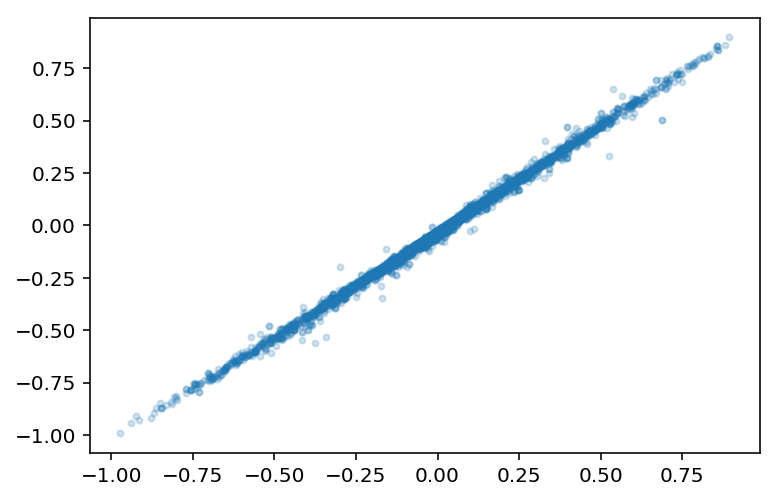

In [28]:
plt.plot(df['e1_input']+0.01,df['e1_res_mean'], '.', alpha = 0.2)

## Case (-0.01,0)

### Model deterministic with PSF

In [ ]:
output_v1 = model_concat_one([tf.cast(image_sheared[1][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_m001_0.csv')

In [29]:
df = pd.read_csv('data/res_det_psf_m001_0.csv')

In [30]:
import statsmodels.api as sm

df_bias_m001_0 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_m001_0['slope_e'+str(k+1)] = np.array(slope)
    df_bias_m001_0['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_m001_0['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_m001_0['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_m001_0['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_m001_0['mean_e'] = np.mean([df_bias_m001_0['slope_e1'],df_bias_m001_0['slope_e2']], axis = 0)
df_bias_m001_0


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.014305,0.004564,0.00077,0.000191,0.012033,0.015127,-0.013232,0.000694,0.000169,-0.008257,0.014716


In [31]:
df_bias_p001_0['mean_e1'][0], df_bias_m001_0['mean_e1'][0]

(-0.026073742765488704, 0.012033178655844001)

In [32]:
(-df_bias_p001_0['mean_e1'][0]+df_bias_m001_0['mean_e1'][0])/0.02

1.9053460710666352

In [33]:
m_e1 = ((-df_bias_p001_0['mean_e1'][0]+df_bias_m001_0['mean_e1'][0])/0.02)-1
m_e2 = ((df_bias_p001_0['mean_e2'][0]-df_bias_m001_0['mean_e2'][0])/0.02)

print(m_e1,m_e2)

0.9053460710666352 -0.0008153504451499129


## Case (0,0.01)

### Model deterministic with PSF

In [ ]:
output_v1 = model_concat_one([tf.cast(image_sheared[2][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_0_p001.csv')

In [34]:
df = pd.read_csv('data/res_det_psf_0_p001.csv')

In [35]:
import statsmodels.api as sm

df_bias_0_p001 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_p001['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_p001['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_p001['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_p001['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_p001['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_p001['mean_e'] = np.mean([df_bias_0_p001['slope_e1'],df_bias_0_p001['slope_e2']], axis = 0)
df_bias_0_p001


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.014107,-0.014535,0.000786,0.000195,-0.007068,0.015327,0.005824,0.000707,0.000172,0.0108,0.014717


## Case (0,-0.01)

In [ ]:
output_v1 = model_concat_one([tf.cast(image_sheared[3][:5000], tf.float32), tf.cast(psf[:5000], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [ ]:
df = pd.DataFrame()
df['e1_res_mean'] = e1_out_mean
df['e2_res_mean'] = e2_out_mean
df['e1_res_std'] = e1_out_std
df['e2_res_std'] = e2_out_std

df['e1_input'] = -e1[:5000]
df['e2_input'] = e2[:5000]

df.to_csv('data/res_det_psf_0_m001.csv')

In [36]:
df = pd.read_csv('data/res_det_psf_0_m001.csv')

In [37]:
import statsmodels.api as sm

df_bias_0_m001 = pd.DataFrame()

for k in range (2):
    slope = []
    intercept = []
    std_slope = []
    std_intercept = []
    mean_e=[]

    x = df['e'+str(k+1)+'_input']+0.01
    #print(x)
    x = sm.add_constant(x, prepend=False)
    lin_reg = sm.OLS(df['e'+str(k+1)+'_res_mean'], x)
    res = lin_reg.fit()
    slope.append(res.params[0]-1)
    intercept.append(res.params[1])
    std_slope.append(res.bse[0])
    std_intercept.append(res.bse[1])
    mean_e.append(np.mean(df['e'+str(k+1)+'_res_mean']))
    
    df_bias_0_m001['slope_e'+str(k+1)] = np.array(slope)
    df_bias_0_m001['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias_0_m001['std_slope'+str(k+1)] = np.array(std_slope)
    df_bias_0_m001['std_intercept'+str(k+1)] = np.array(std_intercept)
    df_bias_0_m001['mean_e'+str(k+1)]=np.array(mean_e)

df_bias_0_m001['mean_e'] = np.mean([df_bias_0_m001['slope_e1'],df_bias_0_m001['slope_e2']], axis = 0)
df_bias_0_m001


,slope_e1,intercept_e1,std_slope1,std_intercept1,mean_e1,slope_e2,intercept_e2,std_slope2,std_intercept2,mean_e2,mean_e
0,0.01341,-0.014441,0.000788,0.000196,-0.006978,0.015098,-0.032333,0.000697,0.00017,-0.027358,0.014254


In [38]:
m_e1 = ((-df_bias_0_p001['mean_e1'][0]+df_bias_0_m001['mean_e1'][0])/0.02)
m_e2 = ((df_bias_0_p001['mean_e2'][0]-df_bias_0_m001['mean_e2'][0])/0.02)-1

print(m_e1,m_e2)

0.004486222165877001 0.9078962894622502


### Combination of posteriors

In [75]:
df = pd.read_csv('data/res_no_psf_0_0.csv')

In [11]:
x = np.linspace(-1,1, 10002)
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

In [81]:
for i in range (len(df['e1_res_mean'])):
    shear_gaussian += gaussian(df['e1_res_mean'][i],df['e1_res_std'][i])

In [82]:
shear_gaussian.shape

(10002,)

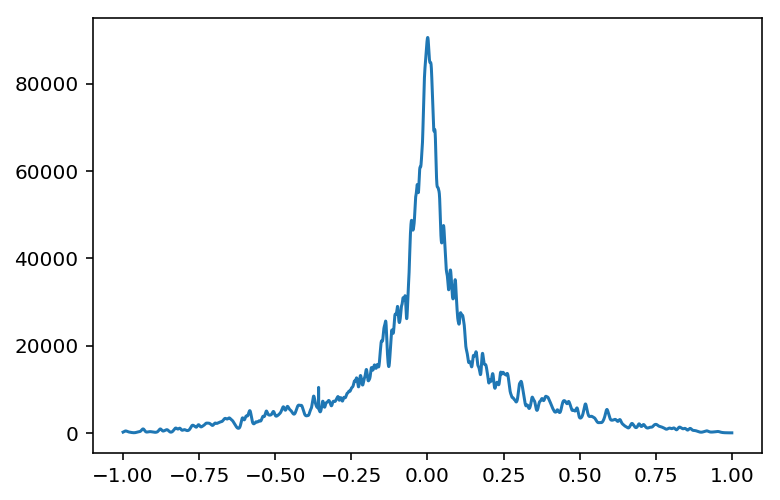

In [84]:
x = np.linspace(-1,1, 10002)
plt.plot(x, shear_gaussian)

In [91]:
np.where(shear_gaussian == np.max(shear_gaussian))

(array([5005]),)

In [93]:
x[5005]

0.0011001100110010764

### test model BNN

In [10]:
names = ['res_bnn_psf_p001_0.csv', 'res_bnn_psf_m001_0.csv', 'res_bnn_psf_0_p001.csv', 'res_bnn_psf_0_m001.csv']
n_images = 1000
for i in range (0,1):
    print(i)
    e1_out_mean = []
    e2_out_mean = []
    e1_out_std = []
    e2_out_std = []
    
    for j in range (10):
        output_v1 = model_bnn([tf.cast(image_sheared[i][:n_images], tf.float32), tf.cast(psf[:n_images], tf.float32)])

        mean = K.get_value(output_v1.mean())
        std = K.get_value(output_v1.stddev())
        
        e1_out_mean.append(mean[:,0])
        e2_out_mean.append(mean[:,1])

        e1_out_std.append(std[:,0])
        e2_out_std.append(std[:,1])
    
    df = pd.DataFrame()
    e1_res_mean = np.zeros((n_images))
    e2_res_mean = np.zeros((n_images))
    e1_res_std = np.zeros((n_images))
    e2_res_std = np.zeros((n_images))
    for k in range(n_images):
        e1_res_mean[k] = np.mean(np.array(e1_out_mean)[:,k])
        e2_res_mean[k] = np.mean(np.array(e2_out_mean)[:,k])
        e1_res_std[k] = np.sqrt(np.mean(np.array(e1_out_std)[:,k]**2))
        e2_res_std[k] = np.sqrt(np.mean(np.array(e2_out_std)[:,k]**2))
    
    df['e1_res_mean'] = e1_res_mean
    df['e2_res_mean'] = e2_res_mean
    df['e1_res_std'] = e1_res_std
    df['e2_res_std'] = e2_res_std

    df['e1_input'] = -e1[:n_images]
    df['e2_input'] = e2[:n_images]

    df.to_csv('data/'+str(names[i]))

0


In [11]:
df_bnn= pd.read_csv('data/res_bnn_psf_p001_0.csv')

### test model Cyrille

In [10]:
names = ['res_cyrille_p001_0.csv', 'res_cyrille_m001_0.csv', 'res_cyrille_0_p001.csv', 'res_cyrille_0_m001.csv']
for i in range (1,2):
    print(i)
    e1_out_mean = []
    e2_out_mean = []
    e1_out_std = []
    e2_out_std = []
    
    output_v1 = model_cyrille([tf.cast(image_sheared[i][:2000], tf.float32), tf.cast(psf[:2000], tf.float32)])
    
    mean = K.get_value(output_v1.mean())
    std = K.get_value(output_v1.stddev())

    df = pd.DataFrame()
    df['e1_res_mean'] = mean[:,0]
    df['e2_res_mean'] = mean[:,1]
    df['e1_res_std'] = np.sqrt(std[:,0]**2)
    df['e2_res_std'] = np.sqrt(std[:,1]**2)

    df['e1_input'] = -e1[:2000]
    df['e2_input'] = e2[:2000]
    
    df.to_csv('data/'+str(names[i]))

1


### Combined distribution

#### e1

In [55]:
df_cyrille= pd.read_csv('data/res_cyrille_p001_0.csv')

In [56]:
df_cyrille.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
Unnamed: 0     2000 non-null int64
e1_res_mean    2000 non-null float64
e2_res_mean    2000 non-null float64
e1_res_std     2000 non-null float64
e2_res_std     2000 non-null float64
e1_input       2000 non-null float64
e2_input       2000 non-null float64
dtypes: float64(6), int64(1)
memory usage: 109.5 KB


(-0.1, 0.1)

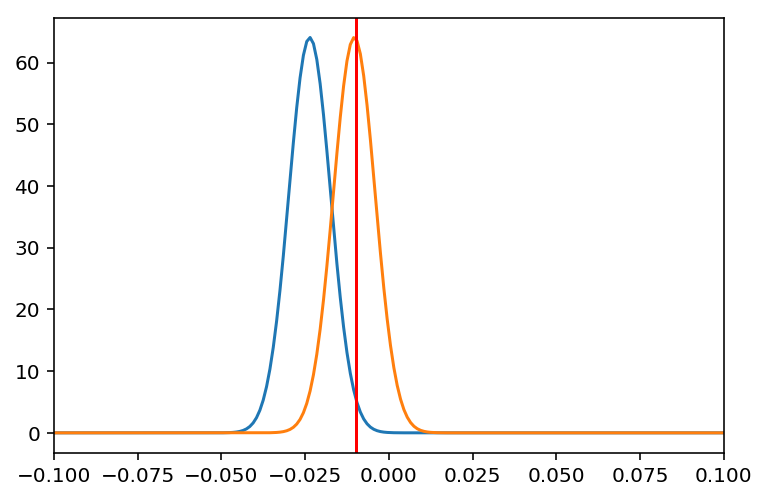

In [57]:
x = np.linspace(-1,1, 2000)
plt.plot(x, gaussian(np.mean(df_cyrille['e1_res_mean']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2))))
plt.plot(x, gaussian(np.mean(df_cyrille['e1_res_mean'])*np.mean(np.min(df_cyrille['e1_res_std'])/df_cyrille['e1_res_std']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2))))
plt.axvline(-np.mean(data['shear_1'])-0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [59]:
print(np.mean(df_cyrille['e1_res_mean']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2)))
print(np.mean(df_cyrille['e1_res_mean']*(np.min(df_cyrille['e1_res_std'])/df_cyrille['e1_res_std'])), np.sqrt(np.mean(df_cyrille['e1_res_std']**2)))

print(np.mean(data['shear_1'][:2000])-0.01)
print(np.mean(data['e1'][:2000])-0.01)
print(np.mean(e1[:2000])-0.01)
print(np.mean(-ellipticity_1[:2000])-0.01)

-0.023619529846494 0.006225641759896183
-0.007875057141332669 0.006225641759896183
-0.010081478358007547
-0.012997069018041797
-0.016045002701699458
-0.015646038352592793


In [37]:
np.mean(data['shear_1'][:2000])+np.mean(data['e1'][:2000])-0.01

-0.013078547376049344

In [42]:
np.mean(-e1[:2000])-0.02

-0.01395499729830054

In [23]:
df_cyrille= pd.read_csv('data/res_cyrille_m001_0.csv')

(-0.1, 0.1)

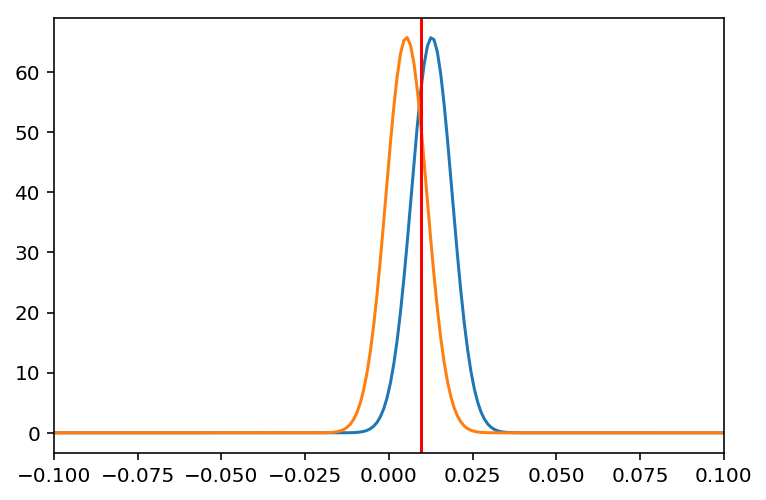

In [24]:
x = np.linspace(-1,1, 2000)
plt.plot(x, gaussian(np.mean(df_cyrille['e1_res_mean']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2))))
plt.plot(x, gaussian(np.mean(df_cyrille['e1_res_mean'])*np.mean(np.min(df_cyrille['e1_res_std'])/df_cyrille['e1_res_std']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2))))
plt.axvline(np.mean(data['shear_1'])+0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [26]:
print(np.mean(df_cyrille['e1_res_mean']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2)))
print(np.mean(df_cyrille['e1_res_mean']*(np.min(df_cyrille['e1_res_std'])/df_cyrille['e1_res_std'])), np.sqrt(np.mean(df_cyrille['e1_res_std']**2)))

print(np.mean(data['shear_1'][:2000])+0.01)
print(np.mean(-e1[:2000])+0.01)

0.01282378671717 0.006063433307738109
0.0038010190105681892 0.006063433307738109
0.009918521641992454
0.016045002701699458


Deterministic network

In [ ]:
df = pd.read_csv('data/res_det_psf_p001_0.csv')

In [ ]:
df.info()

(-0.1, 0.1)

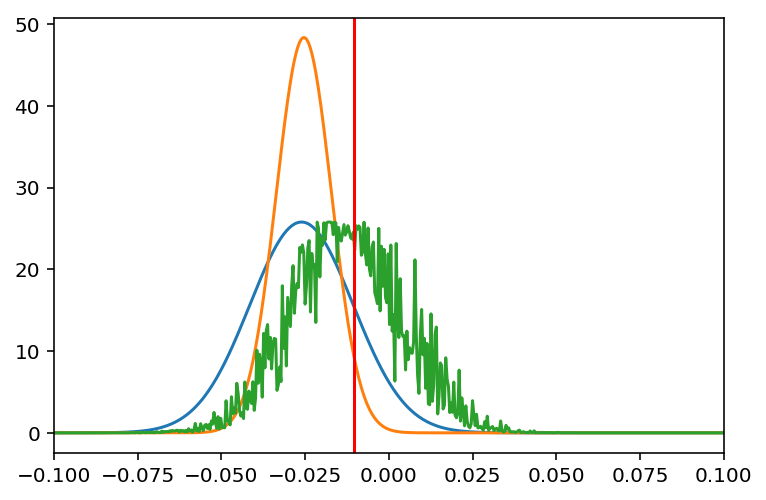

In [23]:
x = np.linspace(-1,1, 5000)
plt.plot(x, gaussian(np.mean(df['e1_res_mean']),np.sqrt(np.mean(df['e1_res_std']**2))))
plt.plot(x, gaussian(np.mean(df['e1_res_mean'])*np.mean(np.min(df['e1_res_std'])/df['e1_res_std']),np.sqrt(np.mean(df['e1_res_std']**2))))
#plt.plot(x, gaussian(np.mean(df_cyrille['e1_res_mean'])*(np.min(df_cyrille['e1_res_std'])/df_cyrille['e1_res_std']),np.sqrt(np.mean(df_cyrille['e1_res_std']**2))))
plt.axvline(np.mean(data['shear_1'])-0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [256]:
print(np.mean(df['e1_res_mean']),np.sqrt(np.mean(df['e1_res_std']**2)))
print(np.mean(df['e1_res_mean']*(np.min(df['e1_res_std'])/df['e1_res_std'])), np.sqrt(np.mean(df['e1_res_std']**2)))

print(np.mean(data['shear_1'])-0.01)

-0.026073742765488704 0.015459217032459876
-0.011187007155465813 0.015459217032459876
-0.010279441537385928


In [250]:
df = pd.read_csv('data/res_det_psf_m001_0.csv')

(-0.1, 0.1)

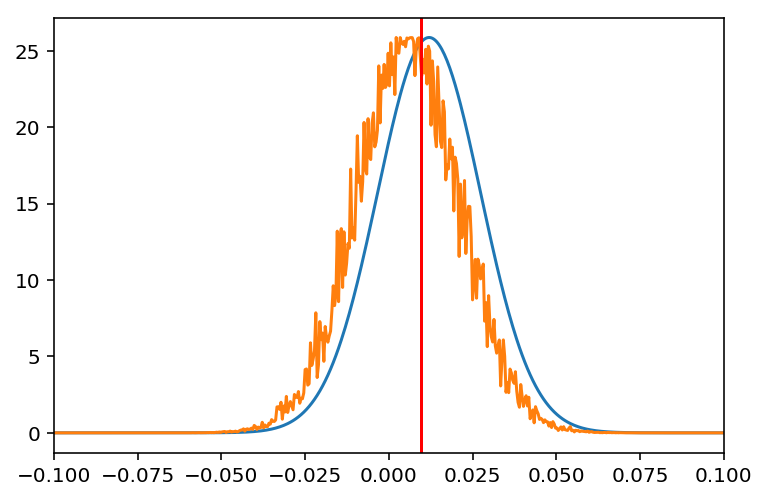

In [251]:
x = np.linspace(-1,1, 5000)
plt.plot(x, gaussian(np.mean(df['e1_res_mean']),np.sqrt(np.mean(df['e1_res_std']**2))))
plt.plot(x, gaussian(np.mean(df['e1_res_mean'])*np.mean(np.min(df['e1_res_std'])/df['e1_res_std']),np.sqrt(np.mean(df['e1_res_std']**2))))
plt.axvline(np.mean(data['shear_1'])+0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [252]:
print(np.mean(df['e1_res_mean']),np.sqrt(np.mean(df['e1_res_std']**2)))
print(np.mean(df['e1_res_mean']*np.mean(np.min(df['e1_res_std'])/df['e1_res_std'])), np.sqrt(np.mean(df['e1_res_std']**2)))

print(np.mean(data['shear_1'])+0.01)
print()

0.012033178655844001 0.015408043580262185
0.0052599900973172445 0.015408043580262185
0.009720558462614073


In [259]:
m_e1_mean = ((0.012033178655844001-(-0.026073742765488704))/0.02)-1
m_e1_pond = ((0.0052599900973172445-(-0.011187007155465813))/0.02)-1

print(m_e1_mean,m_e1_pond)

0.9053460710666352 -0.17765013736084723


#### e2

In [240]:
df = pd.read_csv('data/res_det_psf_0_p001.csv')

(-0.1, 0.1)

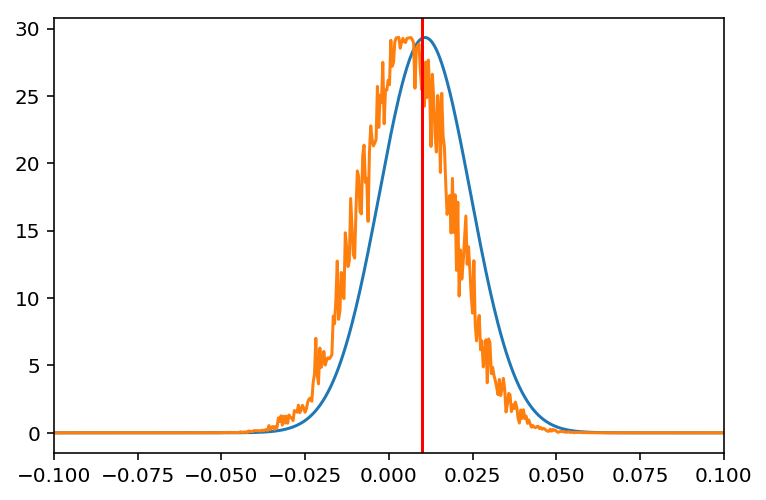

In [242]:
x = np.linspace(-1,1, 5000)
plt.plot(x, gaussian(np.mean(df['e2_res_mean']),np.sqrt(np.mean(df['e2_res_std']**2))))
plt.plot(x, gaussian(np.mean(df['e2_res_mean'])*(np.min(df['e2_res_std'])/df['e2_res_std']),np.sqrt(np.mean(df['e2_res_std']**2))))
plt.axvline(np.mean(data['shear_2'])+0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [244]:
print(np.mean(df['e2_res_mean']),np.sqrt(np.mean(df['e2_res_std']**2)))
print(np.mean(df['e2_res_mean']*(np.min(df['e2_res_std'])/df['e2_res_std'])), np.sqrt(np.mean(df['e2_res_std']**2)))

print(np.mean(data['shear_2'])+0.01)

0.010799806354523 0.013591272322993167
0.0025709714349012335 0.013591272322993167
0.009940061919329004


In [245]:
df = pd.read_csv('data/res_det_psf_0_m001.csv')

(-0.1, 0.1)

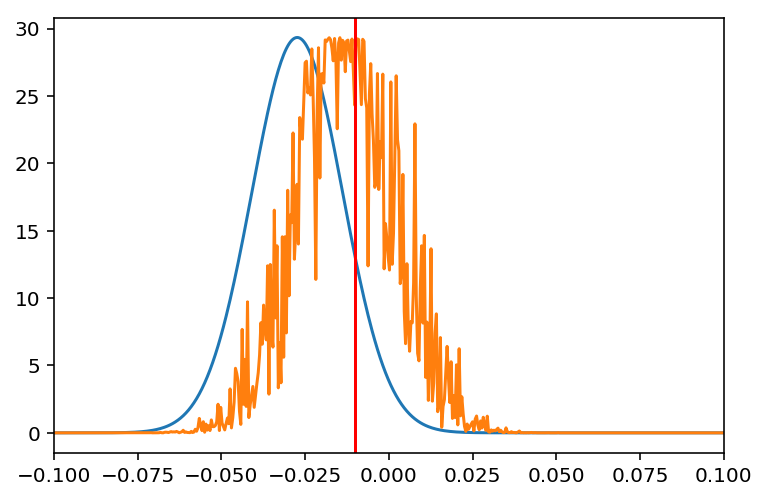

In [246]:
x = np.linspace(-1,1, 5000)
plt.plot(x, gaussian(np.mean(df['e2_res_mean']),np.sqrt(np.mean(df['e2_res_std']**2))))
plt.plot(x, gaussian(np.mean(df['e2_res_mean'])*(np.min(df['e2_res_std'])/df['e2_res_std']),np.sqrt(np.mean(df['e2_res_std']**2))))
plt.axvline(np.mean(data['shear_2'])-0.01, color = 'r')
plt.xlim(-0.1,0.1)

In [248]:
print(np.mean(df['e2_res_mean']),np.sqrt(np.mean(df['e2_res_std']**2)))
print(np.mean(df['e2_res_mean']*(np.min(df['e2_res_std'])/df['e2_res_std'])), np.sqrt(np.mean(df['e2_res_std']**2)))

print(np.mean(data['shear_2'])-0.01)

-0.027358119434722005 0.013589628971427101
-0.012999368814928977 0.013589628971427101
-0.010059938080670997


In [257]:
m_e2_mean = ((0.010799806354523-(-0.027358119434722005))/0.02)-1
m_e2_pond = ((0.0025709714349012335-(-0.012999368814928977))/0.02)-1

print(m_e2_mean,m_e2_pond)

0.9078962894622502 -0.2214829875084895


In [258]:
((0.009940061919329004-(-0.010059938080670997))/0.02)-1

0.0